In [1]:
from bec_gp_solver.geometry import make_geometry
from bec_gp_solver.gp_equation import get_rhs, _H_potential
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

In [9]:
hbar_si = 1.054571800139113e-34
a_si = 5.2917721067e-11
m_ua = 86.909187
m_si = m_ua/6.022140857e23/1000

e_unit = 2*pi*hbar_si * 1960
l_unit = hbar_si/np.sqrt(2*m_si*e_unit)

geo = make_geometry("3d_axial", sizes=(64, 512), lengths=(33.882458170185174, 374.69979774285855))
nx, nz = geo.sizes
n_components = 2
sigma_z = [-1.0, 1.0]
detuning = 0.0
q_zeeman = [0.0, 0.0]
omega_r = 2.7
g_matrix = (8*pi)*np.array([[100.40, 100.40], [100.40, 100.40]]) * (a_si/l_unit)
n_atoms = 1.93369e5
wx, wy, wz = 176.22/1960, 198.53/1960, 27.99/1960
lattice_strength=0.6
k_l=np.sqrt(1-(omega_r/4)**2)
rhs = get_rhs(geo, n_components, sigma_z, detuning, q_zeeman, omega_r, g_matrix, n_atoms, wx, wy, wz, lattice_strength, k_l)

Building radial kinetic energy matrix …
Done.


In [10]:
psi_test = np.load("/home/federico/Documents/projects/bec-gp-solver/example/ground_states/gs_delta_0hz_omega_0.90_5d3753124f.npy")
H_psi = 1j * rhs(0, psi_test)

mu = ((psi_test.conj() * H_psi).reshape((2, nx*nz)) * geo.dv[None, :]).sum().real
active_freqs = [np.sqrt(wx*wy), wz]
U = sum((w*r)**2/4 for w, r, in zip(active_freqs, geo.grids)).reshape(-1)

In [11]:
mu #1.2274485667447526

np.float64(1.2274485667447528)

In [7]:
_H_potential(psi_test.reshape(2, -1), U)

array([[-4.76961718e-09-6.20150427e-10j,  4.95307578e-09-3.26145223e-10j,
        -5.01844996e-09-6.20021534e-10j, ...,
        -1.08102208e-10+1.29635045e-10j,  1.09081422e-10-1.24041325e-10j,
        -1.03385282e-10+1.16646765e-10j],
       [-4.82594652e-09-9.88141258e-11j,  6.48771995e-09+1.28360000e-09j,
        -3.33266162e-09+4.17998746e-11j, ...,
        -1.42871239e-10-6.52554440e-11j,  1.39261487e-10+7.12294807e-11j,
        -1.31496146e-10-7.42533978e-11j]])

In [8]:
geo.dv.sum()

np.float64(1330580.4721976174)

In [25]:
from scipy.integrate import solve_ivp

In [ ]:
sol = solve_ivp(fun=rhs,
                t_span = (0, 100),
                y0=psi_test,
                rtol=1e-6,
                atol=1e-6)

In [6]:
-1j*2*((psi_test.conj() * geo.grad_z(psi_test)).reshape((2, nx*nz)) * geo.dv[None, :]).sum()

np.complex128(-0.018900745292065133+1.329109244106185e-18j)

In [26]:
((active_freqs[0]*geo.grids[0])**2 / 4 + (active_freqs[1]*geo.grids[1])**2 / 4).reshape(-1)

array([1.78990191, 1.77594846, 1.76204963, ..., 4.28145115, 4.29529537,
       4.30919421])

In [10]:
np.sqrt(wx*wy)

np.float64(0.09542992848976599)

In [8]:
U

array([0., 0., 0., ..., 0., 0., 0.])

In [7]:
((np.abs(psi_test)**2).reshape((2, nx*nz)) * geo.dv[None, :]).sum()

np.float64(0.8876240366695215)

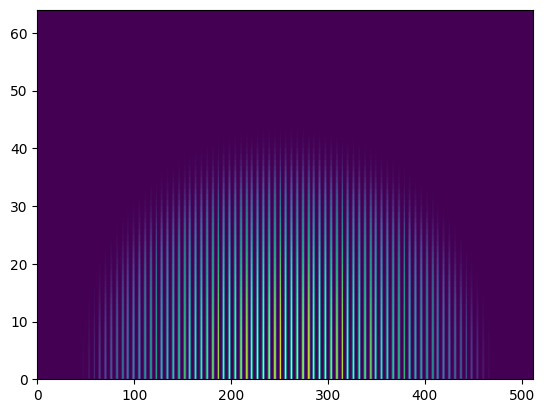

In [21]:
plt.pcolormesh(np.abs(rhs(0, psi_test).reshape((2, 64, 512))[0])**2)

In [23]:
rhs(0, psi_test).max()

np.complex128(0.003843135817946744+0.00043643135083325794j)